In [33]:
# Cell 1 - Imports

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 6)

In [34]:
# Cell 2 - Paths and inputs

BASE_DIR = Path("/Users/tonytony/Final Project")
RAW_DIR = BASE_DIR / "Data" / "Raw"
CLEAN_DIR = BASE_DIR / "Data" / "Cleaned"

GDP_PATH = RAW_DIR / "gdp.csv"

COUNTRY_CODE_INPUT = "VNM"
TARGET_YEAR_INPUT = 2040

MODEL_LABELS = {
    1: "Model 1 - Baseline",
    2: "Model 2 - Extended",
    3: "Model 3 - Full"
}

print("Base dir:", BASE_DIR)
print("GDP path:", GDP_PATH)
print("Country:", COUNTRY_CODE_INPUT)
print("Target year:", TARGET_YEAR_INPUT)

Base dir: /Users/tonytony/Final Project
GDP path: /Users/tonytony/Final Project/Data/Raw/gdp.csv
Country: VNM
Target year: 2040


In [35]:
# Cell 3 - Helper functions

def load_wdi(path):
    df = pd.read_csv(path, skiprows=4)
    df = df.drop(
        columns=[col for col in df.columns if str(col).startswith("Unnamed")],
        errors="ignore"
    )
    return df


def load_actual_gdp_history(country_code):
    df = load_wdi(GDP_PATH)

    row = df[df["Country Code"].astype(str).str.upper() == country_code.upper()].copy()
    if row.empty:
        raise ValueError(f"No GDP history found for country_code={country_code}")

    year_cols = [col for col in df.columns if str(col).isdigit()]
    country_name = str(row.iloc[0]["Country Name"])

    long_df = row.melt(
        id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        value_vars=year_cols,
        var_name="year",
        value_name="actual_gdp_per_capita_usd"
    )

    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce")
    long_df["actual_gdp_per_capita_usd"] = pd.to_numeric(long_df["actual_gdp_per_capita_usd"], errors="coerce")

    long_df = long_df.dropna(subset=["year", "actual_gdp_per_capita_usd"]).copy()
    long_df["year"] = long_df["year"].astype(int)

    return country_name, long_df[["year", "actual_gdp_per_capita_usd"]].sort_values("year").reset_index(drop=True)


def find_forecast_file(model_number, country_code, target_year):
    exact_path = CLEAN_DIR / f"gdp_xgboost_model_{model_number}_future_forecast_{country_code}_{target_year}.csv"

    if exact_path.exists():
        return exact_path

    similar_files = sorted(CLEAN_DIR.glob(f"gdp_xgboost_model_{model_number}_future_forecast_{country_code}_*.csv"))

    if similar_files:
        print(f"Available forecast files for Model {model_number}:")
        for path in similar_files:
            print("-", path.name)

    raise FileNotFoundError(
        f"Forecast file for Model {model_number} was not found for {country_code} and target year {target_year}."
    )


def load_forecast_output(model_number, country_code, target_year):
    file_path = find_forecast_file(model_number, country_code, target_year)
    df = pd.read_csv(file_path)

    required_cols = ["target_year", "predicted_gdp_per_capita_usd"]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns in {file_path.name}: {missing_cols}")

    df["target_year"] = pd.to_numeric(df["target_year"], errors="coerce")
    df["predicted_gdp_per_capita_usd"] = pd.to_numeric(df["predicted_gdp_per_capita_usd"], errors="coerce")

    df = df.dropna(subset=["target_year", "predicted_gdp_per_capita_usd"]).copy()
    df["target_year"] = df["target_year"].astype(int)

    df = df.sort_values("target_year").reset_index(drop=True)
    df["model"] = MODEL_LABELS[model_number]

    return df, file_path

In [36]:
# Cell 4 - Load actual GDP history

country_name_value, actual_gdp_df = load_actual_gdp_history(COUNTRY_CODE_INPUT)
latest_actual_year = int(actual_gdp_df["year"].max())

print("Country name:", country_name_value)
print("Latest actual GDP year:", latest_actual_year)
display(actual_gdp_df.tail(10))

Country name: Viet Nam
Latest actual GDP year: 2024


,year,actual_gdp_per_capita_usd
30,2015,"2,577.5689"
31,2016,"2,735.0604"
32,2017,"2,956.1099"
33,2018,"3,222.3100"
34,2019,"3,440.9003"
35,2020,"3,534.0395"
36,2021,"3,704.1936"
37,2022,"4,147.6978"
38,2023,"4,323.3503"
39,2024,"4,717.2903"


In [37]:
# Cell 5 - Load Model 1, Model 2, Model 3 forecast outputs

model_1_df, model_1_path = load_forecast_output(1, COUNTRY_CODE_INPUT, TARGET_YEAR_INPUT)
model_2_df, model_2_path = load_forecast_output(2, COUNTRY_CODE_INPUT, TARGET_YEAR_INPUT)
model_3_df, model_3_path = load_forecast_output(3, COUNTRY_CODE_INPUT, TARGET_YEAR_INPUT)

print("Model 1 file:", model_1_path.name)
print("Model 2 file:", model_2_path.name)
print("Model 3 file:", model_3_path.name)

display(model_1_df.head())
display(model_2_df.head())
display(model_3_df.head())

Model 1 file: gdp_xgboost_model_1_future_forecast_VNM_2040.csv
Model 2 file: gdp_xgboost_model_2_future_forecast_VNM_2040.csv
Model 3 file: gdp_xgboost_model_3_future_forecast_VNM_2040.csv


,country_name,country_code,wb_region,latest_actual_gdp_year,feature_year_used,target_year,gdp_input_used,population_used,life_expectancy_used,predicted_log_gdp_per_capita,predicted_gdp_per_capita_usd,population_model,life_model,gdp_model,model
0,Viet Nam,VNM,East Asia & Pacific,2024,2024,2025,"4,717.2903","100,987,686.0000",74.8784,8.5280,"5,054.1336",LogHolt,Holt,XGBoost Model 1 Recursive,Model 1 - Baseline
1,Viet Nam,VNM,East Asia & Pacific,2024,2025,2026,"5,054.1336","101,627,204.3534",75.1413,8.5869,"5,361.2283",LogHolt,Holt,XGBoost Model 1 Recursive,Model 1 - Baseline
2,Viet Nam,VNM,East Asia & Pacific,2024,2026,2027,"5,361.2283","102,270,772.5438",75.4042,8.6487,"5,702.8956",LogHolt,Holt,XGBoost Model 1 Recursive,Model 1 - Baseline
3,Viet Nam,VNM,East Asia & Pacific,2024,2027,2028,"5,702.8956","102,918,416.2179",75.6671,8.6959,"5,978.4474",LogHolt,Holt,XGBoost Model 1 Recursive,Model 1 - Baseline
4,Viet Nam,VNM,East Asia & Pacific,2024,2028,2029,"5,978.4474","103,570,161.1842",75.9300,8.7440,"6,273.1973",LogHolt,Holt,XGBoost Model 1 Recursive,Model 1 - Baseline


,country_name,country_code,wb_region,latest_actual_gdp_year,feature_year_used,target_year,gdp_input_used,population_used,life_expectancy_used,inflation_used,unemployment_used,internet_users_used,predicted_log_gdp_per_capita,predicted_gdp_per_capita_usd,population_model,life_model,inflation_model,unemployment_model,internet_model,gdp_model,model
0,Viet Nam,VNM,East Asia & Pacific,2024,2024,2025,"4,717.2903","100,987,686.0000",74.8784,3.6211,1.6020,84.1500,8.5488,"5,160.4620",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive,Model 2 - Extended
1,Viet Nam,VNM,East Asia & Pacific,2024,2025,2026,"5,160.4620","101,627,204.3534",75.1413,3.6211,1.5230,87.7962,8.6160,"5,519.4977",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive,Model 2 - Extended
2,Viet Nam,VNM,East Asia & Pacific,2024,2026,2027,"5,519.4977","102,270,772.5438",75.4042,3.6211,1.5230,91.4425,8.6516,"5,719.3114",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive,Model 2 - Extended
3,Viet Nam,VNM,East Asia & Pacific,2024,2027,2028,"5,719.3114","102,918,416.2179",75.6671,3.6211,1.5230,95.0887,8.7520,"6,323.4418",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive,Model 2 - Extended
4,Viet Nam,VNM,East Asia & Pacific,2024,2028,2029,"6,323.4418","103,570,161.1842",75.9300,3.6211,1.5230,98.7350,8.7517,"6,321.2591",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive,Model 2 - Extended


,country_name,country_code,wb_region,latest_actual_gdp_year,feature_year_used,target_year,gdp_input_used,population_used,life_expectancy_used,inflation_used,unemployment_used,internet_users_used,year_trend_used,asian_financial_crisis_9798,global_financial_crisis_0809,covid_shock_2020,covid_rebound_2021,ukraine_energy_shock_2022_2024,predicted_log_gdp_per_capita,predicted_gdp_per_capita_usd,population_model,life_model,inflation_model,unemployment_model,internet_model,gdp_model,model
0,Viet Nam,VNM,East Asia & Pacific,2024,2024,2025,"4,717.2903","100,987,686.0000",74.8784,3.6211,1.6020,84.1500,33,0,0,0,0,1,8.5775,"5,310.6516",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive,Model 3 - Full
1,Viet Nam,VNM,East Asia & Pacific,2024,2025,2026,"5,310.6516","101,627,204.3534",75.1413,3.6211,1.5230,87.7962,34,0,0,0,0,0,8.7207,"6,128.2237",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive,Model 3 - Full
2,Viet Nam,VNM,East Asia & Pacific,2024,2026,2027,"6,128.2237","102,270,772.5438",75.4042,3.6211,1.5230,91.4425,35,0,0,0,0,0,8.8350,"6,870.3510",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive,Model 3 - Full
3,Viet Nam,VNM,East Asia & Pacific,2024,2027,2028,"6,870.3510","102,918,416.2179",75.6671,3.6211,1.5230,95.0887,36,0,0,0,0,0,8.9444,"7,664.9494",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive,Model 3 - Full
4,Viet Nam,VNM,East Asia & Pacific,2024,2028,2029,"7,664.9494","103,570,161.1842",75.9300,3.6211,1.5230,98.7350,37,0,0,0,0,0,9.0626,"8,626.1651",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive,Model 3 - Full


In [38]:
# Cell 6 - Build comparison table

compare_df = (
    model_1_df[["target_year", "predicted_gdp_per_capita_usd"]]
    .rename(columns={"predicted_gdp_per_capita_usd": "model_1_predicted_gdp"})
    .merge(
        model_2_df[["target_year", "predicted_gdp_per_capita_usd"]]
        .rename(columns={"predicted_gdp_per_capita_usd": "model_2_predicted_gdp"}),
        on="target_year",
        how="inner"
    )
    .merge(
        model_3_df[["target_year", "predicted_gdp_per_capita_usd"]]
        .rename(columns={"predicted_gdp_per_capita_usd": "model_3_predicted_gdp"}),
        on="target_year",
        how="inner"
    )
    .sort_values("target_year")
    .reset_index(drop=True)
)

if compare_df.empty:
    raise ValueError("Comparison table is empty. Check the three forecast outputs.")

print("Forecast year range:", int(compare_df["target_year"].min()), "-", int(compare_df["target_year"].max()))
display(compare_df.head(10))
display(compare_df.tail(10))

Forecast year range: 2025 - 2040


,target_year,model_1_predicted_gdp,model_2_predicted_gdp,model_3_predicted_gdp
0,2025,"5,054.1336","5,160.4620","5,310.6516"
1,2026,"5,361.2283","5,519.4977","6,128.2237"
2,2027,"5,702.8956","5,719.3114","6,870.3510"
3,2028,"5,978.4474","6,323.4418","7,664.9494"
4,2029,"6,273.1973","6,321.2591","8,626.1651"
5,2030,"6,641.9813","6,266.2076","9,881.8201"
6,2031,"7,252.7593","6,407.8055","10,894.3390"
7,2032,"7,560.2698","6,944.7302","11,907.0595"
8,2033,"8,346.5374","7,450.1674","12,378.0771"
9,2034,"9,390.2265","8,409.7301","12,862.3778"


,target_year,model_1_predicted_gdp,model_2_predicted_gdp,model_3_predicted_gdp
6,2031,"7,252.7593","6,407.8055","10,894.3390"
7,2032,"7,560.2698","6,944.7302","11,907.0595"
8,2033,"8,346.5374","7,450.1674","12,378.0771"
9,2034,"9,390.2265","8,409.7301","12,862.3778"
10,2035,"10,239.6441","8,838.9267","13,323.0836"
11,2036,"10,629.0195","9,864.9467","14,922.6827"
12,2037,"11,498.6743","10,913.2958","15,751.5015"
13,2038,"12,270.6281","11,928.6772","15,962.4101"
14,2039,"13,574.6292","13,483.5391","17,602.1929"
15,2040,"15,456.6687","15,878.1157","18,876.7258"


In [39]:
# Cell 7 - Create long-format comparison and summary table

compare_long_df = compare_df.melt(
    id_vars="target_year",
    value_vars=["model_1_predicted_gdp", "model_2_predicted_gdp", "model_3_predicted_gdp"],
    var_name="model_key",
    value_name="predicted_gdp_per_capita_usd"
)

model_name_map = {
    "model_1_predicted_gdp": "Model 1 - Baseline",
    "model_2_predicted_gdp": "Model 2 - Extended",
    "model_3_predicted_gdp": "Model 3 - Full"
}

compare_long_df["model"] = compare_long_df["model_key"].map(model_name_map)

summary_rows = []
first_forecast_year = int(compare_df["target_year"].min())
last_forecast_year = int(compare_df["target_year"].max())
n_periods = last_forecast_year - first_forecast_year

for col_name, model_name in model_name_map.items():
    first_value = float(compare_df[col_name].iloc[0])
    last_value = float(compare_df[col_name].iloc[-1])

    growth_pct = ((last_value / first_value) - 1) * 100 if first_value != 0 else np.nan
    cagr_pct = (((last_value / first_value) ** (1 / n_periods)) - 1) * 100 if n_periods > 0 and first_value > 0 else np.nan

    summary_rows.append(
        {
            "model": model_name,
            "first_forecast_year": first_forecast_year,
            "target_year": last_forecast_year,
            "predicted_gdp_first_year": first_value,
            "predicted_gdp_target_year": last_value,
            "total_growth_pct": growth_pct,
            "cagr_pct": cagr_pct
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values("predicted_gdp_target_year", ascending=False).reset_index(drop=True)
summary_df["rank_at_target_year"] = np.arange(1, len(summary_df) + 1)

display(summary_df)

,model,first_forecast_year,target_year,predicted_gdp_first_year,predicted_gdp_target_year,total_growth_pct,cagr_pct,rank_at_target_year
0,Model 3 - Full,2025,2040,"5,310.6516","18,876.7258",255.4503,8.8225,1
1,Model 2 - Extended,2025,2040,"5,160.4620","15,878.1157",207.6879,7.7806,2
2,Model 1 - Baseline,2025,2040,"5,054.1336","15,456.6687",205.8223,7.7369,3


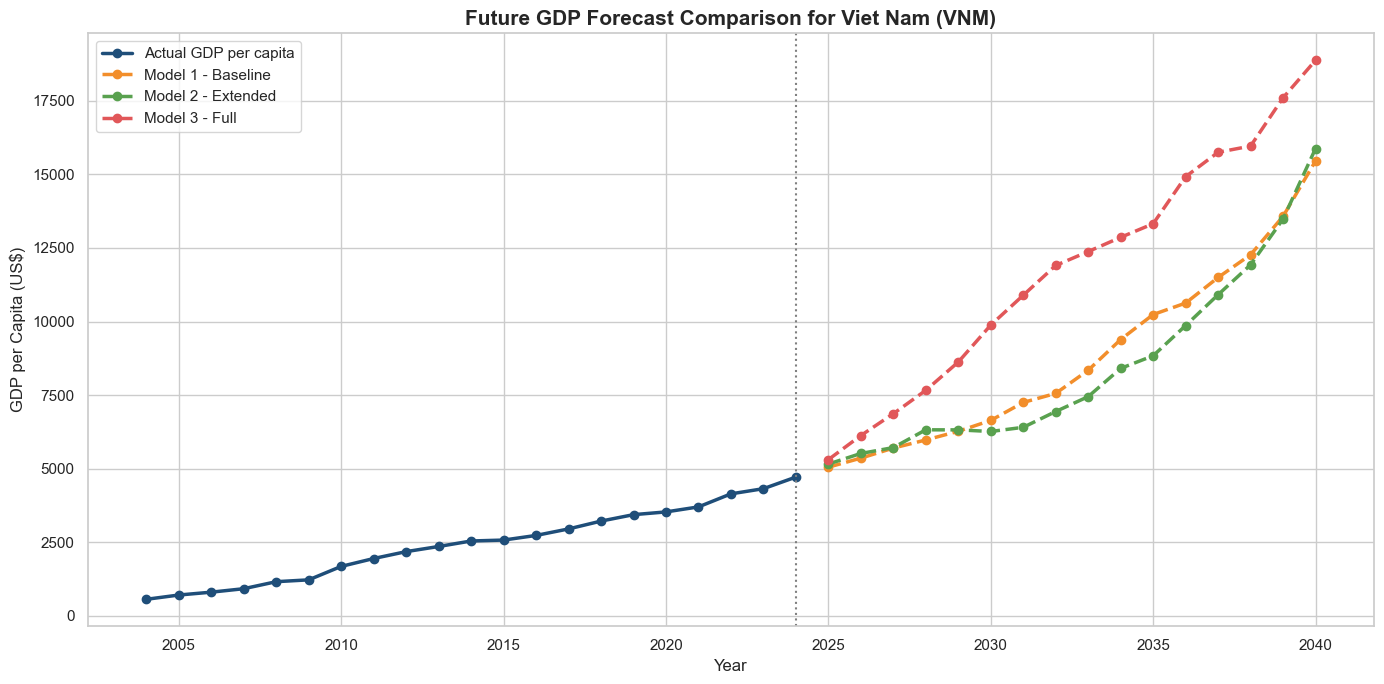

In [40]:
# Cell 8 - Plot actual GDP + 3 future forecast paths

actual_plot_start_year = max(int(actual_gdp_df["year"].min()), latest_actual_year - 20)
actual_plot_df = actual_gdp_df[actual_gdp_df["year"] >= actual_plot_start_year].copy()

plt.figure(figsize=(14, 7))

plt.plot(
    actual_plot_df["year"],
    actual_plot_df["actual_gdp_per_capita_usd"],
    marker="o",
    linewidth=2.5,
    color="#1f4e79",
    label="Actual GDP per capita"
)

plot_style_map = {
    "Model 1 - Baseline": {"color": "#f28e2b", "linestyle": "--"},
    "Model 2 - Extended": {"color": "#59a14f", "linestyle": "--"},
    "Model 3 - Full": {"color": "#e15759", "linestyle": "--"}
}

for model_name, model_df_plot in compare_long_df.groupby("model"):
    plt.plot(
        model_df_plot["target_year"],
        model_df_plot["predicted_gdp_per_capita_usd"],
        marker="o",
        linewidth=2.5,
        linestyle=plot_style_map[model_name]["linestyle"],
        color=plot_style_map[model_name]["color"],
        label=model_name
    )

plt.axvline(x=latest_actual_year, color="gray", linestyle=":", linewidth=1.5)
plt.title(f"Future GDP Forecast Comparison for {country_name_value} ({COUNTRY_CODE_INPUT})", fontsize=15, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("GDP per Capita (US$)")
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/7n/3748sj1972d585qn1zk46ln00000gn/T/ipykernel_75480/3887085294.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


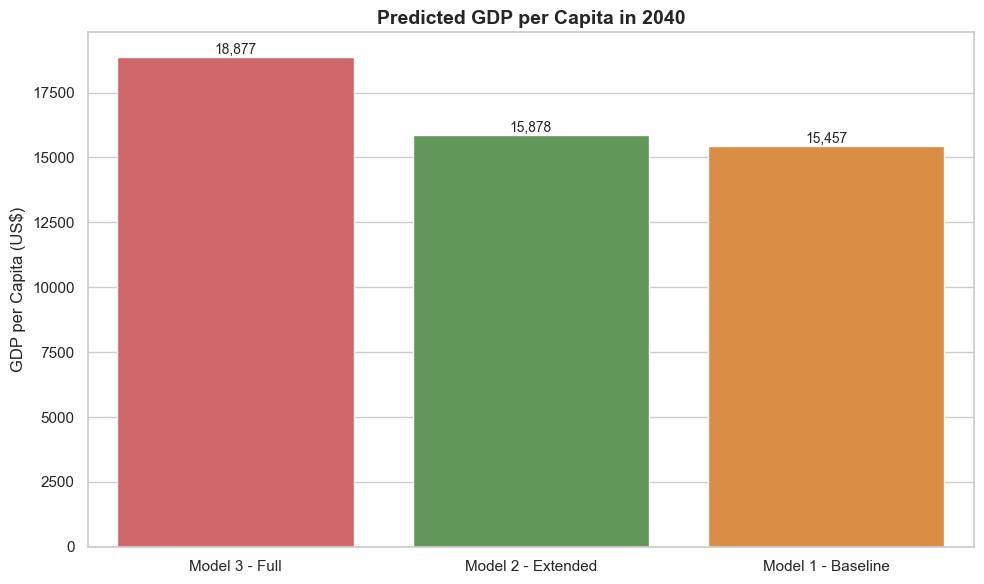

In [41]:
# Cell 9 - Plot target-year comparison bar chart

target_year_df = summary_df[["model", "predicted_gdp_target_year"]].copy()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=target_year_df,
    x="model",
    y="predicted_gdp_target_year",
    palette=["#e15759", "#59a14f", "#f28e2b"]
)

for idx, row in target_year_df.reset_index(drop=True).iterrows():
    ax.text(
        idx,
        row["predicted_gdp_target_year"],
        f'{row["predicted_gdp_target_year"]:,.0f}',
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title(f"Predicted GDP per Capita in {TARGET_YEAR_INPUT}", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.ylabel("GDP per Capita (US$)")
plt.tight_layout()
plt.show()

In [42]:
# Cell 10 - Optional: model gaps relative to Model 1

gap_df = compare_df.copy()
gap_df["model_2_minus_model_1"] = gap_df["model_2_predicted_gdp"] - gap_df["model_1_predicted_gdp"]
gap_df["model_3_minus_model_1"] = gap_df["model_3_predicted_gdp"] - gap_df["model_1_predicted_gdp"]

display(
    gap_df[
        [
            "target_year",
            "model_2_minus_model_1",
            "model_3_minus_model_1"
        ]
    ].head(10)
)

,target_year,model_2_minus_model_1,model_3_minus_model_1
0,2025,106.3284,256.5180
1,2026,158.2694,766.9953
2,2027,16.4158,"1,167.4554"
3,2028,344.9944,"1,686.5020"
4,2029,48.0618,"2,352.9677"
5,2030,-375.7737,"3,239.8389"
6,2031,-844.9538,"3,641.5797"
7,2032,-615.5396,"4,346.7897"
8,2033,-896.3700,"4,031.5397"
9,2034,-980.4964,"3,472.1513"


In [43]:
# Cell 11 - Save comparison outputs

compare_save_path = CLEAN_DIR / f"gdp_xgboost_models_1_2_3_future_compare_{COUNTRY_CODE_INPUT}_{TARGET_YEAR_INPUT}.csv"
summary_save_path = CLEAN_DIR / f"gdp_xgboost_models_1_2_3_future_compare_summary_{COUNTRY_CODE_INPUT}_{TARGET_YEAR_INPUT}.csv"

compare_df.to_csv(compare_save_path, index=False)
summary_df.to_csv(summary_save_path, index=False)

print("Saved comparison table to:", compare_save_path)
print("Saved summary table to:", summary_save_path)

Saved comparison table to: /Users/tonytony/Final Project/Data/Cleaned/gdp_xgboost_models_1_2_3_future_compare_VNM_2040.csv
Saved summary table to: /Users/tonytony/Final Project/Data/Cleaned/gdp_xgboost_models_1_2_3_future_compare_summary_VNM_2040.csv


In [44]:
# Cell 12 - Quick presentation summary

best_target_row = summary_df.iloc[0]

print("=== FUTURE FORECAST COMPARISON SUMMARY ===")
print("Country:", country_name_value, f"({COUNTRY_CODE_INPUT})")
print("Latest actual GDP year:", latest_actual_year)
print("Forecast target year:", TARGET_YEAR_INPUT)
print("Highest target-year forecast:", best_target_row["model"])
print("Predicted GDP per capita at target year:", round(float(best_target_row["predicted_gdp_target_year"]), 2))
print()
print(summary_df[["model", "predicted_gdp_target_year", "total_growth_pct", "cagr_pct"]].round(2).to_string(index=False))

=== FUTURE FORECAST COMPARISON SUMMARY ===
Country: Viet Nam (VNM)
Latest actual GDP year: 2024
Forecast target year: 2040
Highest target-year forecast: Model 3 - Full
Predicted GDP per capita at target year: 18876.73

             model  predicted_gdp_target_year  total_growth_pct  cagr_pct
    Model 3 - Full                18,876.7300          255.4500    8.8200
Model 2 - Extended                15,878.1200          207.6900    7.7800
Model 1 - Baseline                15,456.6700          205.8200    7.7400


In [45]:
# Cell 13 - Metric file paths

metric_paths = {
    "Model 1 - Baseline": CLEAN_DIR / "gdp_xgboost_model_1_metrics.csv",
    "Model 2 - Extended": CLEAN_DIR / "gdp_xgboost_model_2_metrics.csv",
    "Model 3 - Full": CLEAN_DIR / "gdp_xgboost_model_3_metrics.csv",
}

for model_name, path in metric_paths.items():
    print(model_name, "->", path, "| exists:", path.exists())

Model 1 - Baseline -> /Users/tonytony/Final Project/Data/Cleaned/gdp_xgboost_model_1_metrics.csv | exists: True
Model 2 - Extended -> /Users/tonytony/Final Project/Data/Cleaned/gdp_xgboost_model_2_metrics.csv | exists: True
Model 3 - Full -> /Users/tonytony/Final Project/Data/Cleaned/gdp_xgboost_model_3_metrics.csv | exists: True


In [46]:
# Cell 14 - Load and combine metric files

metric_frames = []

for model_name, path in metric_paths.items():
    if not path.exists():
        print(f"Missing metric file for {model_name}: {path.name}")
        continue

    df = pd.read_csv(path).copy()
    df["compare_model_label"] = model_name
    metric_frames.append(df)

if not metric_frames:
    raise FileNotFoundError("No XGBoost metric files were found.")

all_metrics_df = pd.concat(metric_frames, ignore_index=True)

print("Combined metric shape:", all_metrics_df.shape)
display(all_metrics_df.head(10))

Combined metric shape: (12, 11)


,model,model_family,model_note,split,scale,n_obs,MAE,RMSE,MAPE_pct,R_squared,compare_model_label
0,XGBoost Model 1 - Baseline Dynamic,Gradient Boosting ML,"XGBoost version of Model 1 using lag GDP, popu...",train,level_gdp_usd,10117,666.6269,"1,910.2871",10.2075,0.9872,Model 1 - Baseline
1,XGBoost Model 1 - Baseline Dynamic,Gradient Boosting ML,"XGBoost version of Model 1 using lag GDP, popu...",train,log_gdp,10117,0.0922,0.1460,1.3062,0.9930,Model 1 - Baseline
2,XGBoost Model 1 - Baseline Dynamic,Gradient Boosting ML,"XGBoost version of Model 1 using lag GDP, popu...",test,level_gdp_usd,1042,"2,088.0187","5,968.9899",10.2253,0.9598,Model 1 - Baseline
3,XGBoost Model 1 - Baseline Dynamic,Gradient Boosting ML,"XGBoost version of Model 1 using lag GDP, popu...",test,log_gdp,1042,0.0991,0.1390,1.1325,0.9910,Model 1 - Baseline
4,XGBoost Model 2 - Extended Dynamic,Gradient Boosting ML,"XGBoost version of Model 2 with lag GDP, popul...",train,level_gdp_usd,3909,835.3499,"1,753.9447",8.1265,0.9897,Model 2 - Extended
5,XGBoost Model 2 - Extended Dynamic,Gradient Boosting ML,"XGBoost version of Model 2 with lag GDP, popul...",train,log_gdp,3909,0.0805,0.1115,1.0148,0.9949,Model 2 - Extended
6,XGBoost Model 2 - Extended Dynamic,Gradient Boosting ML,"XGBoost version of Model 2 with lag GDP, popul...",test,level_gdp_usd,813,"1,858.3526","4,168.2013",12.3253,0.9663,Model 2 - Extended
7,XGBoost Model 2 - Extended Dynamic,Gradient Boosting ML,"XGBoost version of Model 2 with lag GDP, popul...",test,log_gdp,813,0.1162,0.1559,1.3562,0.9879,Model 2 - Extended
8,XGBoost Model 3 - Full Dynamic,Gradient Boosting ML,"XGBoost version of Model 3 with lag GDP, extra...",train,level_gdp_usd,3909,709.2771,"1,583.4757",6.9785,0.9916,Model 3 - Full
9,XGBoost Model 3 - Full Dynamic,Gradient Boosting ML,"XGBoost version of Model 3 with lag GDP, extra...",train,log_gdp,3909,0.0691,0.1000,0.8858,0.9959,Model 3 - Full


In [47]:
# Cell 15 - Test metrics only

test_metrics_df = all_metrics_df[all_metrics_df["split"] == "test"].copy()

display(test_metrics_df)

,model,model_family,model_note,split,scale,n_obs,MAE,RMSE,MAPE_pct,R_squared,compare_model_label
2,XGBoost Model 1 - Baseline Dynamic,Gradient Boosting ML,"XGBoost version of Model 1 using lag GDP, popu...",test,level_gdp_usd,1042,"2,088.0187","5,968.9899",10.2253,0.9598,Model 1 - Baseline
3,XGBoost Model 1 - Baseline Dynamic,Gradient Boosting ML,"XGBoost version of Model 1 using lag GDP, popu...",test,log_gdp,1042,0.0991,0.1390,1.1325,0.9910,Model 1 - Baseline
6,XGBoost Model 2 - Extended Dynamic,Gradient Boosting ML,"XGBoost version of Model 2 with lag GDP, popul...",test,level_gdp_usd,813,"1,858.3526","4,168.2013",12.3253,0.9663,Model 2 - Extended
7,XGBoost Model 2 - Extended Dynamic,Gradient Boosting ML,"XGBoost version of Model 2 with lag GDP, popul...",test,log_gdp,813,0.1162,0.1559,1.3562,0.9879,Model 2 - Extended
10,XGBoost Model 3 - Full Dynamic,Gradient Boosting ML,"XGBoost version of Model 3 with lag GDP, extra...",test,level_gdp_usd,813,"1,716.3037","4,110.5737",9.9803,0.9672,Model 3 - Full
11,XGBoost Model 3 - Full Dynamic,Gradient Boosting ML,"XGBoost version of Model 3 with lag GDP, extra...",test,log_gdp,813,0.0966,0.1333,1.1113,0.9911,Model 3 - Full


In [48]:
# Cell 16 - Test metrics comparison on GDP level

test_level_metrics_df = (
    test_metrics_df[test_metrics_df["scale"] == "level_gdp_usd"]
    [
        [
            "compare_model_label",
            "n_obs",
            "MAE",
            "RMSE",
            "MAPE_pct",
            "R_squared"
        ]
    ]
    .sort_values(["RMSE", "MAE"])
    .reset_index(drop=True)
)

display(test_level_metrics_df)

,compare_model_label,n_obs,MAE,RMSE,MAPE_pct,R_squared
0,Model 3 - Full,813,"1,716.3037","4,110.5737",9.9803,0.9672
1,Model 2 - Extended,813,"1,858.3526","4,168.2013",12.3253,0.9663
2,Model 1 - Baseline,1042,"2,088.0187","5,968.9899",10.2253,0.9598


In [49]:
# Cell 17 - Test metrics comparison on log GDP

test_log_metrics_df = (
    test_metrics_df[test_metrics_df["scale"] == "log_gdp"]
    [
        [
            "compare_model_label",
            "n_obs",
            "MAE",
            "RMSE",
            "MAPE_pct",
            "R_squared"
        ]
    ]
    .sort_values(["RMSE", "MAE"])
    .reset_index(drop=True)
)

display(test_log_metrics_df)

,compare_model_label,n_obs,MAE,RMSE,MAPE_pct,R_squared
0,Model 3 - Full,813,0.0966,0.1333,1.1113,0.9911
1,Model 1 - Baseline,1042,0.0991,0.1390,1.1325,0.9910
2,Model 2 - Extended,813,0.1162,0.1559,1.3562,0.9879


In [50]:
# Cell 18 - Rank models on test GDP level

ranked_level_metrics_df = test_level_metrics_df.copy()

ranked_level_metrics_df["rank_RMSE"] = ranked_level_metrics_df["RMSE"].rank(method="min")
ranked_level_metrics_df["rank_MAE"] = ranked_level_metrics_df["MAE"].rank(method="min")
ranked_level_metrics_df["rank_MAPE"] = ranked_level_metrics_df["MAPE_pct"].rank(method="min")
ranked_level_metrics_df["rank_R2"] = ranked_level_metrics_df["R_squared"].rank(ascending=False, method="min")

ranked_level_metrics_df["average_rank"] = ranked_level_metrics_df[
    ["rank_RMSE", "rank_MAE", "rank_MAPE", "rank_R2"]
].mean(axis=1)

ranked_level_metrics_df = ranked_level_metrics_df.sort_values(
    ["average_rank", "RMSE", "MAE"]
).reset_index(drop=True)

display(ranked_level_metrics_df)

,compare_model_label,n_obs,MAE,RMSE,MAPE_pct,R_squared,rank_RMSE,rank_MAE,rank_MAPE,rank_R2,average_rank
0,Model 3 - Full,813,"1,716.3037","4,110.5737",9.9803,0.9672,1.0000,1.0000,1.0000,1.0000,1.0000
1,Model 2 - Extended,813,"1,858.3526","4,168.2013",12.3253,0.9663,2.0000,2.0000,3.0000,2.0000,2.2500
2,Model 1 - Baseline,1042,"2,088.0187","5,968.9899",10.2253,0.9598,3.0000,3.0000,2.0000,3.0000,2.7500


/var/folders/7n/3748sj1972d585qn1zk46ln00000gn/T/ipykernel_75480/2201496010.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/7n/3748sj1972d585qn1zk46ln00000gn/T/ipykernel_75480/2201496010.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/7n/3748sj1972d585qn1zk46ln00000gn/T/ipykernel_75480/2201496010.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/7n/3748sj1972d585qn1zk46ln00000gn/T/ipykernel_75480/2201496010.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated an

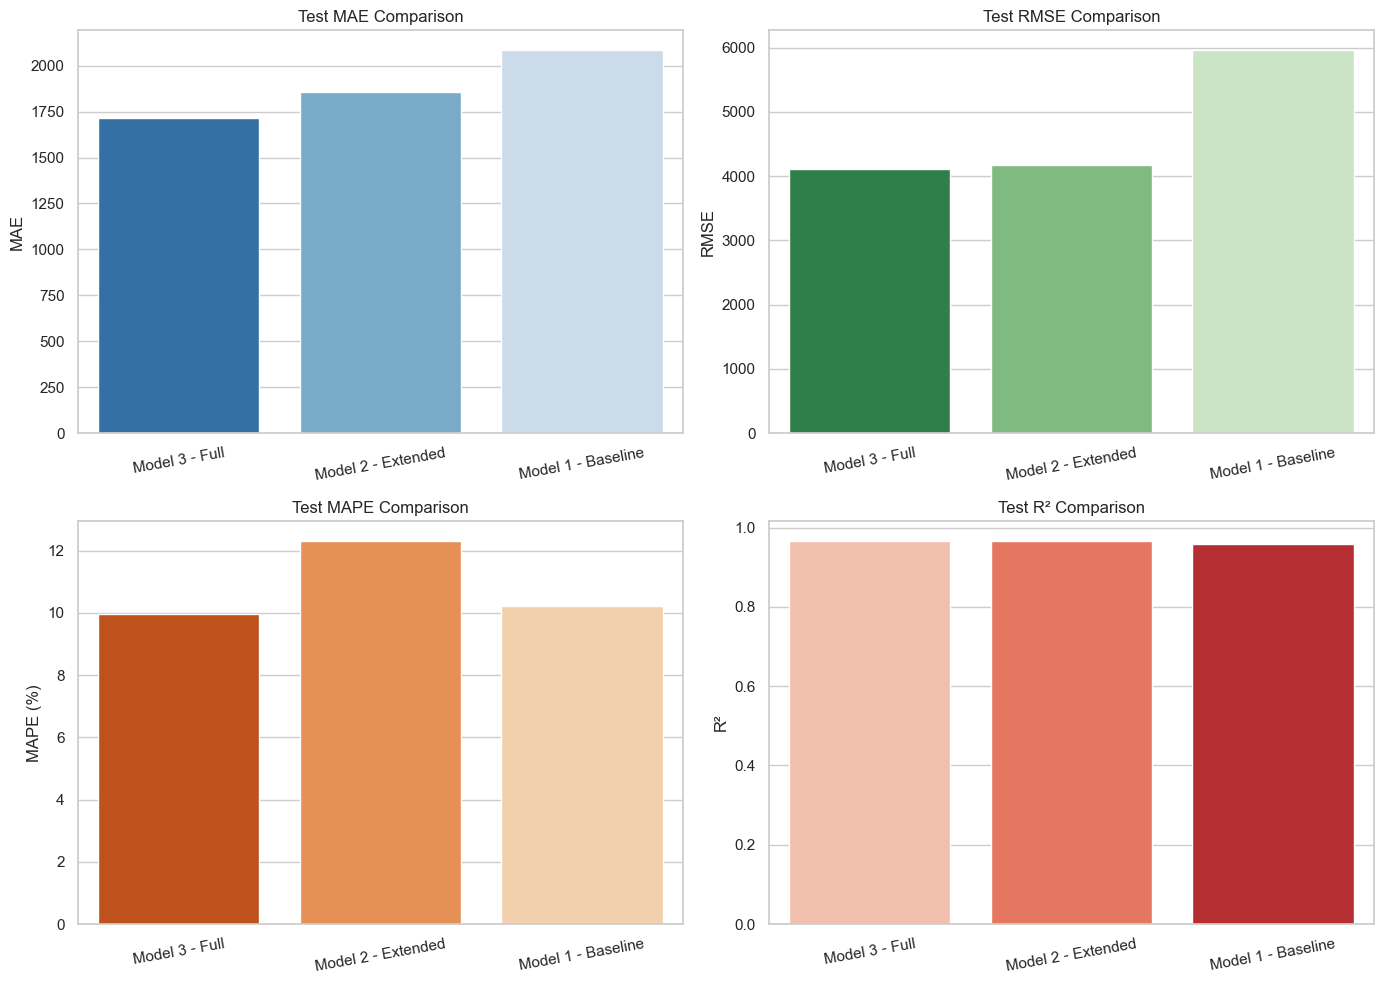

In [51]:
# Cell 19 - Visual comparison of test metrics

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(
    data=test_level_metrics_df,
    x="compare_model_label",
    y="MAE",
    ax=axes[0, 0],
    palette="Blues_r"
)
axes[0, 0].set_title("Test MAE Comparison")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("MAE")

sns.barplot(
    data=test_level_metrics_df,
    x="compare_model_label",
    y="RMSE",
    ax=axes[0, 1],
    palette="Greens_r"
)
axes[0, 1].set_title("Test RMSE Comparison")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("RMSE")

sns.barplot(
    data=test_level_metrics_df,
    x="compare_model_label",
    y="MAPE_pct",
    ax=axes[1, 0],
    palette="Oranges_r"
)
axes[1, 0].set_title("Test MAPE Comparison")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("MAPE (%)")

sns.barplot(
    data=test_level_metrics_df,
    x="compare_model_label",
    y="R_squared",
    ax=axes[1, 1],
    palette="Reds"
)
axes[1, 1].set_title("Test R² Comparison")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("R²")

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.show()